In [27]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

import cv2
import numpy as np
from PIL import Image
import os
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [28]:

class VideoLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout=0.5):
        super(VideoLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,  
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  
        )
        
         
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),   
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
         
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),   
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def attention_net(self, lstm_output):
         
        attention_weights = self.attention(lstm_output)   
        attention_weights = torch.softmax(attention_weights, dim=1)   
        context = torch.sum(attention_weights * lstm_output, dim=1)   
        return context
    
    def forward(self, x):
         
         
        lstm_out, _ = self.lstm(x)   
        
         
        attn_out = self.attention_net(lstm_out)   
        
         
        output = self.classifier(attn_out)
        return output

In [29]:
 
def load_model(model_path):
    checkpoint = torch.load(model_path)
    
     
    arch = checkpoint['architecture']
    loaded_model = VideoLSTM(
        input_dim=arch['input_dim'],
        hidden_dim=arch['hidden_dim'],
        num_layers=arch['num_layers'],
        num_classes=arch['num_classes'],
        dropout=arch['dropout']
    )
    
     
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()   
    
    return loaded_model

 
model_path = './models/df_lstm_model.pt'
model = load_model(model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [30]:
 
def get_feature_extractor(device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = models.resnext101_32x8d(pretrained=True)
    
     
    feature_extractor = nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval()   
    feature_extractor.to(device)
    
    return feature_extractor

 
feature_extractor = get_feature_extractor(device)
print("Feature extractor loaded successfully!")

C:\Users\SARAN\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\SARAN\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Feature extractor loaded successfully!


In [31]:
 
transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406],
              std=[0.229, 0.224, 0.225])
])

 
def extract_frames(video_path, num_frames=8):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = max(total_frames // num_frames, 1)
    frames = []
    
    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = Image.fromarray(frame)
        frame = transform(frame)
        frames.append(frame)
    
    cap.release()
    
     
    while len(frames) < num_frames:
        frames.append(torch.zeros_like(frames[0]))
    
    return torch.stack(frames)   

In [32]:
 
def extract_video_features(frames, feature_extractor):
    with torch.no_grad():
         
        features = []
        for frame in frames:
             
            frame = frame.unsqueeze(0).to(device)
            feature = feature_extractor(frame)
             
            feature = feature.squeeze()
            features.append(feature.cpu())
        
         
        features_tensor = torch.stack(features)
         
        features_tensor = features_tensor.unsqueeze(0)
    
    return features_tensor

In [33]:
 
def predict_video(video_path, model, feature_extractor, threshold=0.5):
     
    frames = extract_frames(video_path)
    
     
    features = extract_video_features(frames, feature_extractor)
    
     
    with torch.no_grad():
        features = features.to(device)
        outputs = model(features)
        probabilities = F.softmax(outputs, dim=1)
        fake_prob = probabilities[0, 1].item()   
        predicted_class = 1 if fake_prob > threshold else 0
    
    result = {
        'path': video_path,
        'fake_probability': fake_prob,
        'predicted_class': predicted_class,
        'prediction': 'FAKE' if predicted_class == 1 else 'REAL'
    }
    
    return result

In [34]:
 
def predict_folder(folder_path, model, feature_extractor, threshold=0.5):
    results = []
    video_extensions = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
    
     
    video_files = []
    for file in os.listdir(folder_path):
        if file.lower().endswith(video_extensions):
            video_files.append(os.path.join(folder_path, file))
    
    if not video_files:
        print(f"No video files found in {folder_path}")
        return results
    
     
    for video_path in tqdm(video_files, desc="Processing videos"):
        try:
            result = predict_video(video_path, model, feature_extractor, threshold)
            results.append(result)
        except Exception as e:
            print(f"Error processing {video_path}: {str(e)}")
    
    return results

In [35]:
 
threshold = 0.5

 
folder_path = './videos_to_predict'

 
if not os.path.exists(folder_path):
    print(f"Folder {folder_path} does not exist. Creating it now.")
    os.makedirs(folder_path)
    print(f"Please put videos to analyze in {folder_path} and run this cell again.")
else:
     
    results = predict_folder(folder_path, model, feature_extractor, threshold)
    
    if results:
         
        print("\nPrediction Results:")
        for result in results:
            print(f"Video: {os.path.basename(result['path'])}")
            print(f"Prediction: {result['prediction']} (confidence: {result['fake_probability']:.4f})")
            print("-" * 80)

Processing videos: 100%|██████████| 8/8 [00:04<00:00,  1.79it/s]


Prediction Results:
Video: 01_02__outside_talking_still_laughing__YVGY8LOK.mp4
Prediction: FAKE (confidence: 0.7875)
--------------------------------------------------------------------------------
Video: fake.mp4
Prediction: FAKE (confidence: 0.8037)
--------------------------------------------------------------------------------
Video: fake_trump.mp4
Prediction: FAKE (confidence: 0.8440)
--------------------------------------------------------------------------------
Video: id0_id3_0000.mp4
Prediction: REAL (confidence: 0.0752)
--------------------------------------------------------------------------------
Video: real.mp4
Prediction: REAL (confidence: 0.2655)
--------------------------------------------------------------------------------
Video: vs35.mp4
Prediction: FAKE (confidence: 0.7892)
--------------------------------------------------------------------------------
Video: WhatsApp Video 2025-05-02 at 14.05.45_49b3d8d6.mp4
Prediction: FAKE (confidence: 0.7155)
----------------

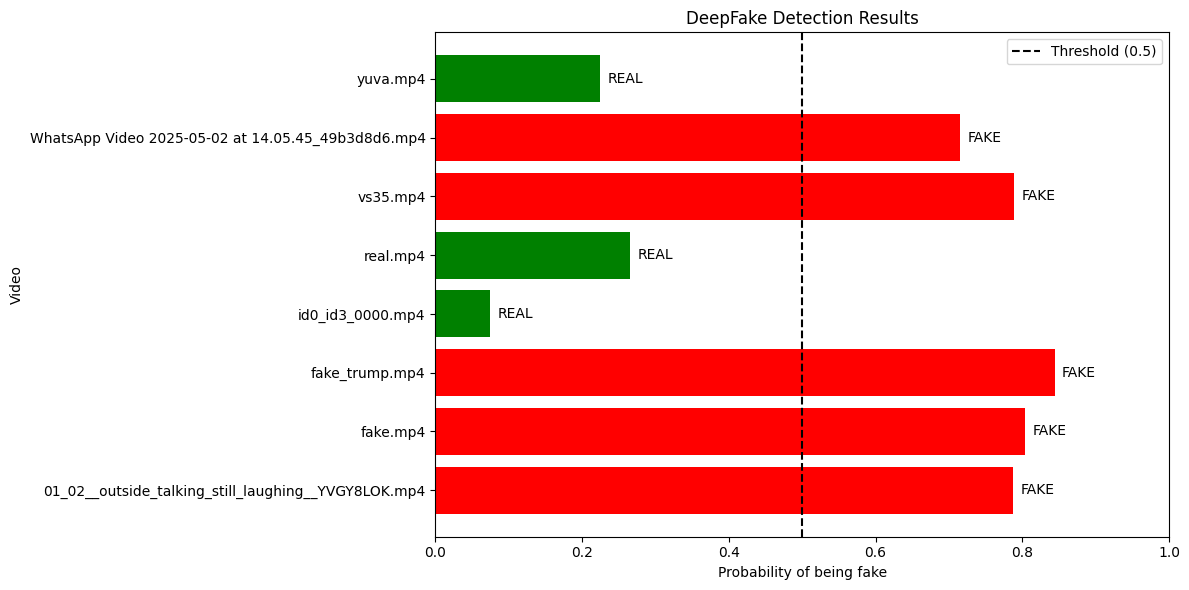

In [36]:
 
def visualize_results(results):
    if not results:
        print("No results to visualize.")
        return
    
     
    video_names = [os.path.basename(r['path']) for r in results]
    probabilities = [r['fake_probability'] for r in results]
    predictions = [r['prediction'] for r in results]
    
     
    colors = ['red' if p == 'FAKE' else 'green' for p in predictions]
    
     
    plt.figure(figsize=(12, 6))
    bars = plt.barh(video_names, probabilities, color=colors)
    plt.xlabel('Probability of being fake')
    plt.ylabel('Video')
    plt.title('DeepFake Detection Results')
    plt.axvline(x=threshold, color='black', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlim(0, 1)
    
     
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                 predictions[i], va='center')
    
    plt.tight_layout()
    plt.legend()
    plt.show()

 
if 'results' in locals() and results:
    visualize_results(results)

In [37]:
 
def analyze_video_frames(video_path, model, feature_extractor):
     
    frames = extract_frames(video_path)
    
     
    with torch.no_grad():
        frame_features = []
        for frame in frames:
             
            frame_tensor = frame.unsqueeze(0).to(device)
            feature = feature_extractor(frame_tensor)
             
            feature = feature.squeeze().cpu()
            frame_features.append(feature)
        
         
        features_tensor = torch.stack(frame_features).unsqueeze(0).to(device)
        
         
        outputs = model(features_tensor)
        probabilities = F.softmax(outputs, dim=1)
        fake_prob = probabilities[0, 1].item()
        
         
        lstm_out, _ = model.lstm(features_tensor)
        attention_weights = model.attention(lstm_out)
        attention_weights = torch.softmax(attention_weights, dim=1).squeeze().cpu().numpy()
    
     
    frame_images = []
    for frame in frames:
         
        img = frame.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        frame_images.append(img)
    
     
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f"Video Analysis: {os.path.basename(video_path)} - Fake Probability: {fake_prob:.4f}", fontsize=16)
    
    for i, (img, weight) in enumerate(zip(frame_images, attention_weights)):
        row, col = i // 4, i % 4
        axs[row, col].imshow(img)
        axs[row, col].set_title(f"Frame {i}: Weight {weight[0]:.4f}")
        axs[row, col].axis('off')
        
         
        if weight[0] > 0.15:   
            axs[row, col].patch.set_edgecolor('red')
            axs[row, col].patch.set_linewidth(4)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    return fake_prob, attention_weights

In [38]:
 
def select_video_for_analysis(folder_path):
    video_extensions = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
    video_files = []
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(video_extensions):
            video_files.append(file)
    
    if not video_files:
        print(f"No video files found in {folder_path}")
        return None
    
    print("Available videos:")
    for i, file in enumerate(video_files):
        print(f"{i+1}. {file}")
    
    choice = int(input(f"\nSelect a video to analyze (1-{len(video_files)}): "))
    if 1 <= choice <= len(video_files):
        return os.path.join(folder_path, video_files[choice-1])
    else:
        print("Invalid choice.")
        return None

 
 
 
 

In [39]:
 
import pandas as pd

def export_results_to_csv(results, output_path='./prediction_results.csv'):
    if not results:
        print("No results to export.")
        return
    
     
    df = pd.DataFrame([
        {
            'Video': os.path.basename(r['path']),
            'Prediction': r['prediction'],
            'Fake_Probability': r['fake_probability'],
            'Full_Path': r['path']
        } for r in results
    ])
    
     
    df.to_csv(output_path, index=False)
    print(f"Results exported to {output_path}")
    
    return df

 
if 'results' in locals() and results:
    df = export_results_to_csv(results)
    display(df)

Results exported to ./prediction_results.csv


,Video,Prediction,Fake_Probability,Full_Path
0,01_02__outside_talking_still_laughing__YVGY8LO...,FAKE,0.787476,./videos_to_predict\01_02__outside_talking_sti...
1,fake.mp4,FAKE,0.803687,./videos_to_predict\fake.mp4
2,fake_trump.mp4,FAKE,0.843963,./videos_to_predict\fake_trump.mp4
3,id0_id3_0000.mp4,REAL,0.075169,./videos_to_predict\id0_id3_0000.mp4
4,real.mp4,REAL,0.265545,./videos_to_predict\real.mp4
5,vs35.mp4,FAKE,0.789241,./videos_to_predict\vs35.mp4
6,WhatsApp Video 2025-05-02 at 14.05.45_49b3d8d6...,FAKE,0.715465,./videos_to_predict\WhatsApp Video 2025-05-02 ...
7,yuva.mp4,REAL,0.224385,./videos_to_predict\yuva.mp4
